In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos los datasets reunidos

In [2]:
df = pd.read_csv('Ies_dept_muni_sex_car_orig.csv',sep=';')
display(df.head())

,IES,CARACTER,DEPARTAMENTO,MUNICIPIO,ORIGEN,SEXO,TIPO,1998-1,1998-2,1999-1,...,2020-1,2020-2,2021-1,2021-2,2022-1,2022-2,2023-1,2023-2,2024-1,2024-2
0,1101,Universidad,"Bogotá, d. c.","Bogotá, D.C.",Oficial,Mujer,DESERTORES,0.0,0.0,45.0,...,649.0,764.0,528.0,359.0,833.0,770.0,623.0,972.0,1167.0,987.0
1,1101,Universidad,"Bogotá, d. c.","Bogotá, D.C.",Oficial,Sin informaci¿n,DESERTORES,NaN,NaN,NaN,...,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,1101,Universidad,"Bogotá, d. c.","Bogotá, D.C.",Oficial,Hombre,DESERTORES,0.0,0.0,106.0,...,457.0,406.0,261.0,160.0,328.0,267.0,217.0,271.0,318.0,206.0
3,1102,Universidad,Antioquia,Medellín,Oficial,Mujer,DESERTORES,0.0,0.0,40.0,...,553.0,906.0,115.0,281.0,676.0,651.0,583.0,1025.0,1021.0,866.0
4,1102,Universidad,Antioquia,Medellín,Oficial,Sin informaci¿n,DESERTORES,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
domicilio_IES_valores = list(df['DEPARTAMENTO'].unique())
print(domicilio_IES_valores)


['Bogotá, d. c.', 'Antioquia', 'Caldas', 'Valle del Cauca', 'Boyacá', 'Cauca', 'Risaralda', 'Córdoba', 'Huila', 'Caquetá', 'Chocó', 'Meta', 'Cesar', 'Arauca', 'Amazonas', 'Atlántico', 'Santander', 'Bolívar', 'Nariño', 'Tolima', 'Quindío', 'Norte de Santander', 'Magdalena', 'Cundinamarca', 'Sucre', 'La Guajira', 'Casanare', 'Putumayo', 'Archipiélago de San Andrés y Providencia']


Debemos empezar a limpiar los datos primero arrancamos por domicilio de las IES

In [4]:
import unicodedata

def limpieza_total(texto):
    if not isinstance(texto, str):
        return texto
    
    texto = texto.lower()
    
    texto_normalizado = unicodedata.normalize('NFD', texto)
    texto_sin_puntuacion = "".join(
        c for c in texto_normalizado 
        if unicodedata.category(c) != 'Mn' and not unicodedata.category(c).startswith('P')
    )
    texto_limpio = " ".join(texto_sin_puntuacion.split())
    
    return texto_limpio
df['DEPARTAMENTO'] = df['DEPARTAMENTO'].apply(limpieza_total)
df['MUNICIPIO'] = df['MUNICIPIO'].apply(limpieza_total)
dic = {'archipielago de sa':'san andres y providencia','san andres y provi':'san andres y providencia','archipielago de san andres providencia y santa catalina':'san andres y providencia','narinio':'narino','la guajira':'guajira'}
# matriculados['Departamento de domicilio de la IES'] = matriculados['Departamento de domicilio de la IES'].replace(dic)


In [5]:

print(df['DEPARTAMENTO'].value_counts())
print(df.shape)

DEPARTAMENTO
bogota d c                                  548
antioquia                                   222
valle del cauca                             140
santander                                    94
atlantico                                    78
bolivar                                      62
cundinamarca                                 54
risaralda                                    32
norte de santander                           32
cauca                                        30
boyaca                                       30
tolima                                       30
caldas                                       26
narino                                       26
cesar                                        20
magdalena                                    18
quindio                                      18
sucre                                        18
huila                                        16
cordoba                                      14
choco                      

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1562 entries, 0 to 1561
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   IES           1562 non-null   int64  
 1   CARACTER      1562 non-null   object 
 2   DEPARTAMENTO  1562 non-null   object 
 3   MUNICIPIO     1562 non-null   object 
 4   ORIGEN        1562 non-null   object 
 5   SEXO          1562 non-null   object 
 6   TIPO          1562 non-null   object 
 7   1998-1        848 non-null    float64
 8   1998-2        852 non-null    float64
 9   1999-1        886 non-null    float64
 10  1999-2        910 non-null    float64
 11  2000-1        930 non-null    float64
 12  2000-2        948 non-null    float64
 13  2001-1        1002 non-null   float64
 14  2001-2        1016 non-null   float64
 15  2002-1        1040 non-null   float64
 16  2002-2        1042 non-null   float64
 17  2003-1        1070 non-null   float64
 18  2003-2        1082 non-null 

Transformamos nuestra tabla de tipo ancha (wide) a larga (long) con el objetivo de volver los años en una variable periodo y los desertados valor en una sola columna, esto nos ayuda a poder unir con la tabla anterior. 

In [7]:
columnas_stay = ['SEXO','ORIGEN','MUNICIPIO','DEPARTAMENTO','CARACTER','IES','TIPO']
columnas_melt = [col for col in df.columns if df[col].dtype in ['float64','float32']]
print(columnas_melt)

['1998-1', '1998-2', '1999-1', '1999-2', '2000-1', '2000-2', '2001-1', '2001-2', '2002-1', '2002-2', '2003-1', '2003-2', '2004-1', '2004-2', '2005-1', '2005-2', '2006-1', '2006-2', '2007-1', '2007-2', '2008-1', '2008-2', '2009-1', '2009-2', '2010-1', '2010-2', '2011-1', '2011-2', '2012-1', '2012-2', '2013-1', '2013-2', '2014-1', '2014-2', '2015-1', '2015-2', '2016-1', '2016-2', '2017-1', '2017-2', '2018-1', '2018-2', '2019-1', '2019-2', '2020-1', '2020-2', '2021-1', '2021-2', '2022-1', '2022-2', '2023-1', '2023-2', '2024-1', '2024-2']


In [8]:

long = df.melt(
    id_vars=columnas_stay,
    value_vars=columnas_melt,       # lista de '2015-1', '2015-2', ...
    var_name='periodo',
    value_name='valor'
)
display(long.head())

,SEXO,ORIGEN,MUNICIPIO,DEPARTAMENTO,CARACTER,IES,TIPO,periodo,valor
0,Mujer,Oficial,bogota dc,bogota d c,Universidad,1101,DESERTORES,1998-1,0.0
1,Sin informaci¿n,Oficial,bogota dc,bogota d c,Universidad,1101,DESERTORES,1998-1,NaN
2,Hombre,Oficial,bogota dc,bogota d c,Universidad,1101,DESERTORES,1998-1,0.0
3,Mujer,Oficial,medellin,antioquia,Universidad,1102,DESERTORES,1998-1,0.0
4,Sin informaci¿n,Oficial,medellin,antioquia,Universidad,1102,DESERTORES,1998-1,NaN


In [9]:
# PASO 2 - Pivot TIPO
# Separa DESERTORES y MATRICULADOS en columnas propias.
# aggfunc con min_count=1: si el unico valor del grupo es NaN,
# el resultado queda NaN (hueco real) en lugar de 0 (cero falso).
pivot = long.pivot_table(
    index=["IES","DEPARTAMENTO","MUNICIPIO","SEXO","periodo","ORIGEN","CARACTER"],
    columns="TIPO",
    values="valor",
    aggfunc=lambda x: x.sum(min_count=1)
).reset_index()
display(pivot.head())

TIPO,IES,DEPARTAMENTO,MUNICIPIO,SEXO,periodo,ORIGEN,CARACTER,DESERTORES,MATRICULADOS
0,1101,bogota d c,bogota dc,Hombre,1998-1,Oficial,Universidad,0.0,1264.0
1,1101,bogota d c,bogota dc,Hombre,1998-2,Oficial,Universidad,0.0,2286.0
2,1101,bogota d c,bogota dc,Hombre,1999-1,Oficial,Universidad,106.0,3435.0
3,1101,bogota d c,bogota dc,Hombre,1999-2,Oficial,Universidad,243.0,4515.0
4,1101,bogota d c,bogota dc,Hombre,2000-1,Oficial,Universidad,314.0,5632.0


In [10]:
# Version con SEXO desagregado: se usara en el dashboard.
# min_count=1 preserva NaN cuando todos los valores del grupo son NaN.
agg_base = pivot.groupby(
    ["IES","DEPARTAMENTO","MUNICIPIO","CARACTER","ORIGEN","periodo"]
).agg(
    DESERTORES   = ("DESERTORES",   lambda x: x.sum(min_count=1)),
    MATRICULADOS = ("MATRICULADOS", lambda x: x.sum(min_count=1))
).reset_index()

# Tasa solo donde MATRICULADOS > 0; huecos y ausencias quedan NaN.
agg_base["tasa"] = np.where(
    agg_base["MATRICULADOS"] > 0,
    (agg_base["DESERTORES"] / agg_base["MATRICULADOS"] * 100).round(2),
    np.nan
)
display(agg_base.isna().sum())

IES             0
DEPARTAMENTO    0
MUNICIPIO       0
CARACTER        0
ORIGEN          0
periodo         0
DESERTORES      0
MATRICULADOS    0
tasa            0
dtype: int64

In [11]:
# Diagnostico de cobertura para forecasting
# Umbral: >= 20 periodos consecutivos sin huecos internos (10 anios)

UMBRAL = 20

# Orden canonico de periodos (por anio y semestre)
all_periods = sorted(agg_base["periodo"].unique(),
                     key=lambda p: (int(p.split("-")[0]), int(p.split("-")[1])))
periodo_idx = {p: i for i, p in enumerate(all_periods)}

def diagnostico_ies(grupo):
    periodos   = sorted(grupo["periodo"].tolist(),
                        key=lambda p: (int(p.split("-")[0]), int(p.split("-")[1])))
    idx_inicio = periodo_idx[periodos[0]]
    idx_fin    = periodo_idx[periodos[-1]]

    esperados = set(all_periods[idx_inicio : idx_fin + 1])
    faltantes = sorted(esperados - set(periodos),
                       key=lambda p: (int(p.split("-")[0]), int(p.split("-")[1])))
    longitud  = idx_fin - idx_inicio + 1

    if faltantes:
        clasificacion = "hueco_interno"
    elif longitud >= UMBRAL:
        clasificacion = "apta"
    else:
        clasificacion = "serie_corta"

    return pd.Series({
        "primer_periodo":     periodos[0],
        "ultimo_periodo":     periodos[-1],
        "longitud_serie":     longitud,
        "n_reportados":       len(periodos),
        "n_faltantes":        len(faltantes),
        "periodos_faltantes": ", ".join(faltantes) if faltantes else "",
        "clasificacion":      clasificacion
    })

cobertura_forecast = agg_base.groupby("IES").apply(diagnostico_ies).reset_index()

print(cobertura_forecast["clasificacion"].value_counts())
print(f"\nIES aptas para forecasting (>= {UMBRAL} periodos consecutivos): "
      f"{(cobertura_forecast['clasificacion'] == 'apta').sum()}")
display(cobertura_forecast.head(20))

clasificacion
apta             277
hueco_interno     46
serie_corta       20
Name: count, dtype: int64

IES aptas para forecasting (>= 20 periodos consecutivos): 277


C:\Users\Jonathan Piedrahita\AppData\Local\Temp\ipykernel_22096\3840305893.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cobertura_forecast = agg_base.groupby("IES").apply(diagnostico_ies).reset_index()


,IES,primer_periodo,ultimo_periodo,longitud_serie,n_reportados,n_faltantes,periodos_faltantes,clasificacion
0,1101,1998-1,2024-2,54,54,0,,apta
1,1102,1998-1,2024-2,54,54,0,,apta
2,1103,1998-1,2024-2,54,54,0,,apta
3,1104,1998-1,2024-2,54,54,0,,apta
4,1105,1998-1,2024-2,54,54,0,,apta
5,1106,1998-1,2024-2,54,54,0,,apta
6,1107,1998-1,2024-2,54,54,0,,apta
7,1108,1998-1,2024-2,54,54,0,,apta
8,1109,1998-1,2024-2,54,54,0,,apta
9,1110,1998-1,2024-2,54,52,2,"2002-1, 2020-2",hueco_interno


In [12]:
display(agg_base['IES'].value_counts())

IES
9122    54
1208    54
1207    54
1206    54
1205    54
        ..
2906     5
3802     4
9918     1
9132     1
9938     1
Name: count, Length: 343, dtype: int64

In [13]:
ies_aptas = cobertura_forecast.loc[cobertura_forecast["clasificacion"] == "apta", "IES"]
df_forecast = agg_base[agg_base["IES"].isin(ies_aptas)].copy()
display(df_forecast.info())
display(df_forecast.nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 13668 entries, 0 to 15334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   IES           13668 non-null  int64  
 1   DEPARTAMENTO  13668 non-null  object 
 2   MUNICIPIO     13668 non-null  object 
 3   CARACTER      13668 non-null  object 
 4   ORIGEN        13668 non-null  object 
 5   periodo       13668 non-null  object 
 6   DESERTORES    13668 non-null  float64
 7   MATRICULADOS  13668 non-null  float64
 8   tasa          13668 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.0+ MB


None

IES              277
DEPARTAMENTO      28
MUNICIPIO         67
CARACTER           4
ORIGEN             2
periodo           54
DESERTORES      1964
MATRICULADOS    6879
tasa            3233
dtype: int64

### Creamos graficas para ver como se comporta los datos

1. Panorama general de deserción

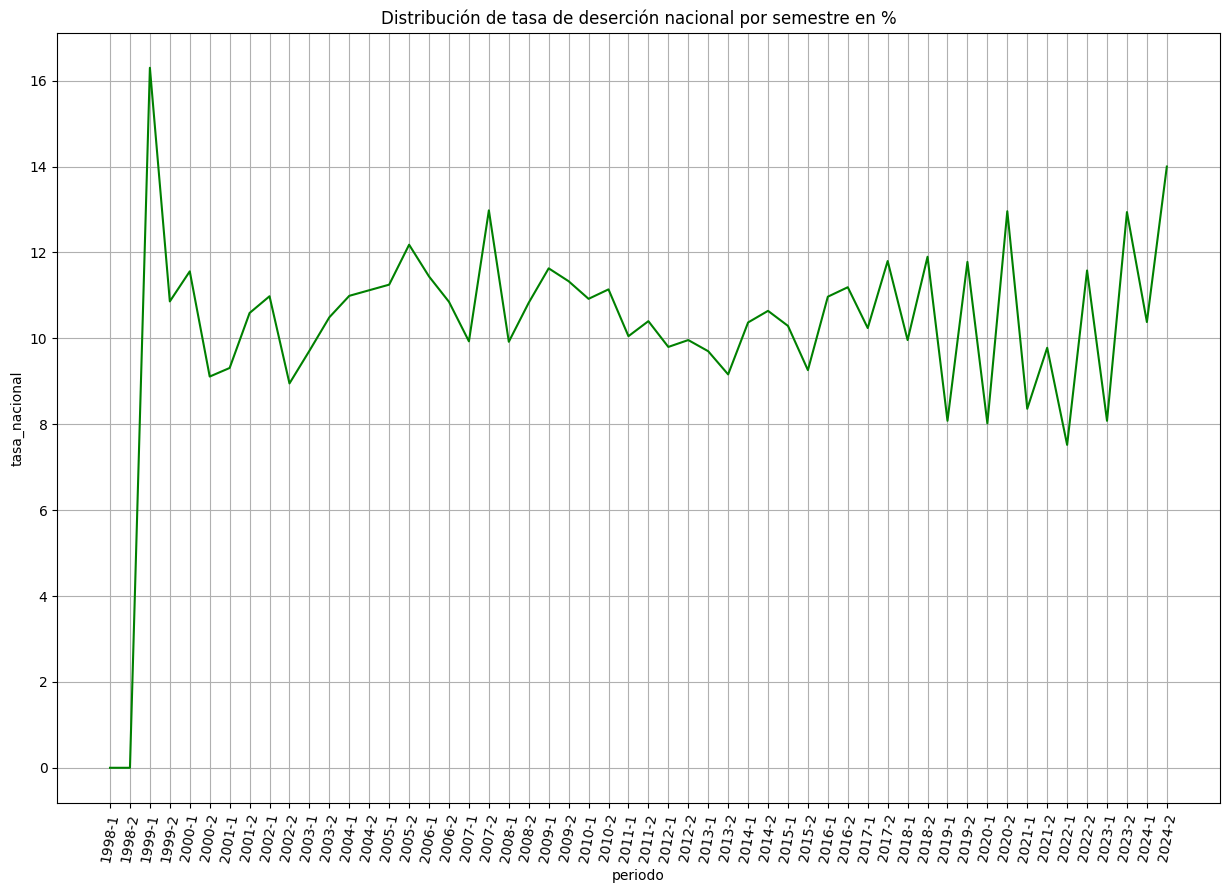

In [14]:
promedio = df_forecast.groupby('periodo').agg(
    desertores_total = ('DESERTORES','sum'),
    matriculados_total = ('MATRICULADOS','sum')   
)
promedio['tasa_nacional'] = ((promedio['desertores_total'] / promedio['matriculados_total'])*100).round(2)
# display(promedio.head())
fig = plt.figure(figsize=(15,10))
sns.lineplot(data=promedio,x='periodo',y='tasa_nacional',color='green')
plt.title('Distribución de tasa de deserción nacional por semestre en %')
plt.xticks(rotation=80)
plt.grid()
plt.show()

2. Distribución de IES

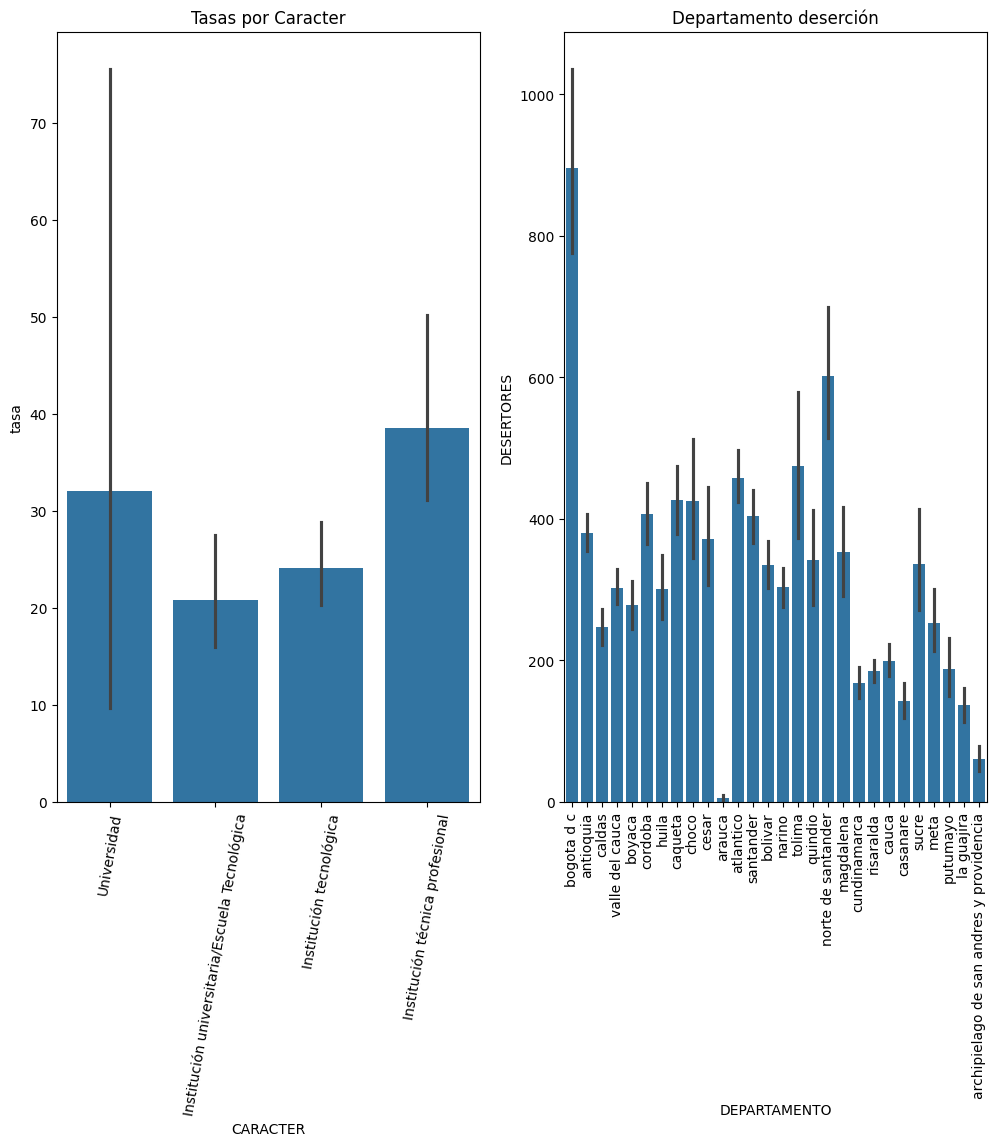

In [15]:
fig,axs = plt.subplots(1,2,figsize=(12,10))
axs[0].set_title('Tasas por Caracter')
sns.barplot(data=df_forecast,x='CARACTER',y='tasa',ax=axs[0])
axs[0].tick_params(axis='x',rotation=80)
axs[1].set_title('Departamento deserción')
sns.barplot(data=df_forecast,x='DEPARTAMENTO',y='DESERTORES',ax=axs[1])
axs[1].tick_params(axis='x',rotation=90)
plt.tight_layout
plt.show()

3. Calidad del dataset para el modelo

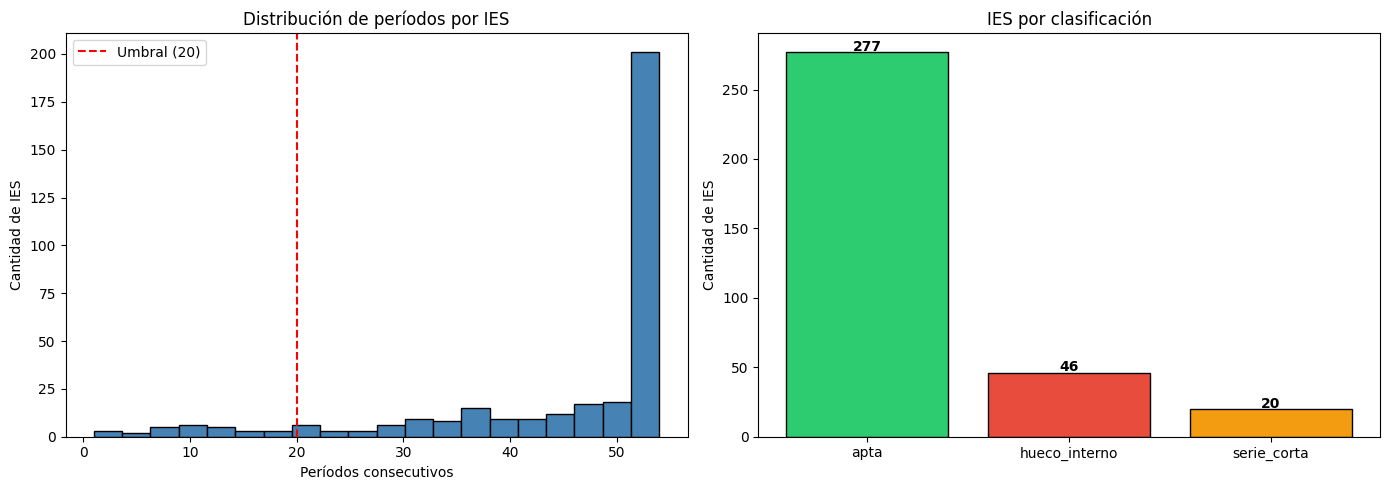

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma de longitud de serie por IES
axs[0].hist(cobertura_forecast['longitud_serie'], bins=20, color='steelblue', edgecolor='black')
axs[0].axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='Umbral (20)')
axs[0].set_title('Distribución de períodos por IES')
axs[0].set_xlabel('Períodos consecutivos')
axs[0].set_ylabel('Cantidad de IES')
axs[0].legend()

# 2. Barras aptas vs descartadas
conteo = cobertura_forecast['clasificacion'].value_counts()
colores = {'apta': '#2ecc71', 'hueco_interno': '#e74c3c', 'serie_corta': '#f39c12'}
axs[1].bar(conteo.index, conteo.values,
           color=[colores[c] for c in conteo.index], edgecolor='black')
axs[1].set_title('IES por clasificación')
axs[1].set_ylabel('Cantidad de IES')
for i, v in enumerate(conteo.values):
    axs[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


4. Ejemplo de serie individual

Una o dos IES específicas con su serie de tasa a lo largo del tiempo — muestra qué tan "limpia" o volátil es la señal que el modelo va a aprender

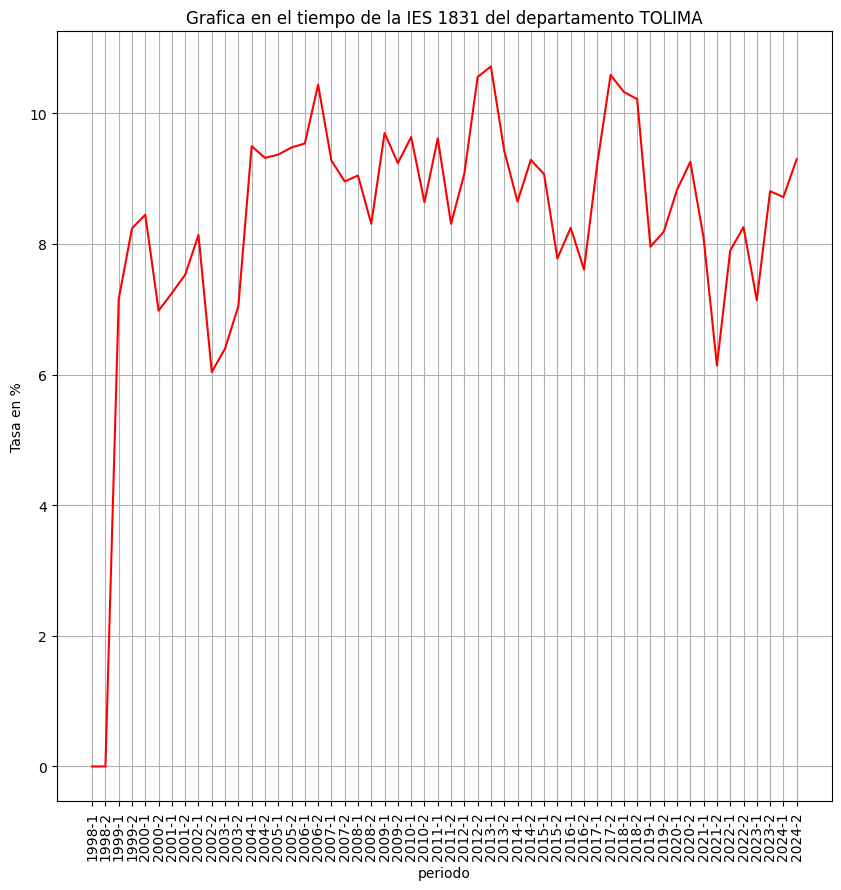

In [17]:
# una IES aleatoria
np.random.seed(42)
ies = np.random.choice(list(df_forecast['IES'].unique()))
# Filtramos esa IES en especifico
s = df_forecast.loc[df_forecast['IES'] == ies]
# print(s['IES'].values[0])
fig = plt.figure(figsize=(10,10))
plt.title(f"Grafica en el tiempo de la IES {s['IES'].iloc[0]} del departamento {s['DEPARTAMENTO'].iloc[0].upper()}")
sns.lineplot(data=s,x='periodo',y='tasa',color='red')
plt.ylabel('Tasa en %')
plt.xticks(rotation=90)
plt.grid()
plt.show()


In [18]:
display(df_forecast.head(20))

,IES,DEPARTAMENTO,MUNICIPIO,CARACTER,ORIGEN,periodo,DESERTORES,MATRICULADOS,tasa
0,1101,bogota d c,bogota dc,Universidad,Oficial,1998-1,0.0,2219.0,0.00
1,1101,bogota d c,bogota dc,Universidad,Oficial,1998-2,0.0,4118.0,0.00
2,1101,bogota d c,bogota dc,Universidad,Oficial,1999-1,151.0,6079.0,2.48
3,1101,bogota d c,bogota dc,Universidad,Oficial,1999-2,396.0,7934.0,4.99
4,1101,bogota d c,bogota dc,Universidad,Oficial,2000-1,469.0,9926.0,4.72
5,1101,bogota d c,bogota dc,Universidad,Oficial,2000-2,551.0,11506.0,4.79
6,1101,bogota d c,bogota dc,Universidad,Oficial,2001-1,741.0,13420.0,5.52
7,1101,bogota d c,bogota dc,Universidad,Oficial,2001-2,678.0,14889.0,4.55
8,1101,bogota d c,bogota dc,Universidad,Oficial,2002-1,804.0,16159.0,4.98
9,1101,bogota d c,bogota dc,Universidad,Oficial,2002-2,849.0,17598.0,4.82


In [19]:
path_save = r"df_forecast_raw.csv"
df_forecast.to_csv(path_save,index=False)